In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
# ── 1. LOAD DATA ─────────────────────────────────────────────
df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.shape)       # (7043, 21)
print(df.head())
print(df.info())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [3]:
# ── 2. FIX MISSING VALUES ────────────────────────────────────
# TotalCharges has blank strings — convert to numeric first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [4]:
# Fill missing TotalCharges with the column mean
avg_total = df['TotalCharges'].mean()
df['TotalCharges'].fillna(avg_total, inplace=True)

print(df.isnull().sum())  # confirm no more nulls

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


C:\Users\Arij\AppData\Local\Temp\ipykernel_6764\1961870752.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(avg_total, inplace=True)


In [5]:
# ── 3. ENCODE CATEGORICAL → NUMERIC ──────────────────────────
# Convert Churn to binary: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [6]:
# Drop CustomerID (not useful for ML)
df.drop('customerID', axis=1, inplace=True)

In [7]:
# One-hot encode all remaining categorical columns
df_encoded = pd.get_dummies(df)
print(df_encoded.shape)

(7043, 46)


In [8]:
# ── 4. TRAIN / VALIDATION / TEST SPLIT ───────────────────────
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [9]:
# Step 1: split off 10% test set
X_remaining, X_test, y_remaining, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

In [10]:
# Step 2: split remaining into 80% train, 10% val
X_train, X_val, y_train, y_val = train_test_split(
    X_remaining, y_remaining, test_size=0.111, random_state=42  # 0.111 ≈ 10/90
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 5634, Val: 704, Test: 705


In [11]:
# Check and fix NaN in y
print("NaN in y_train:", y_train.isna().sum())
print("NaN in y_val:", y_val.isna().sum())

# Fix: drop NaN rows
y_train = y_train.dropna()
X_train = X_train.loc[y_train.index]

y_val = y_val.dropna()
X_val = X_val.loc[y_val.index]

print("Fixed! y_train values:", y_train.unique())

NaN in y_train: 0
NaN in y_val: 0
Fixed! y_train values: [1 0]


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Train
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

c:\Users\Arij\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [13]:
from sklearn.metrics import classification_report

print("--- Logistic Regression ---")
print(classification_report(y_val, lr.predict(X_val)))

print("--- Random Forest ---")
print(classification_report(y_val, rf.predict(X_val)))

print("--- Decision Tree ---")
print(classification_report(y_val, dt.predict(X_val)))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.93      0.73      0.82       526
           1       0.51      0.83      0.63       178

    accuracy                           0.75       704
   macro avg       0.72      0.78      0.72       704
weighted avg       0.82      0.75      0.77       704

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.87       526
           1       0.62      0.46      0.52       178

    accuracy                           0.79       704
   macro avg       0.72      0.68      0.70       704
weighted avg       0.78      0.79      0.78       704

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       526
           1       0.51      0.51      0.51       178

    accuracy                           0.75       704
   macro avg       0.67      0.67      0.67       704
we

In [14]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,        # add this
    random_state=42
)

In [16]:
# Re-train Random Forest with max_depth=10
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    random_state=42
)
rf_tuned.fit(X_train, y_train)

# Check results
from sklearn.metrics import classification_report
print("--- Random Forest TUNED ---")
print(classification_report(y_val, rf_tuned.predict(X_val)))

--- Random Forest TUNED ---
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       526
           1       0.54      0.69      0.61       178

    accuracy                           0.78       704
   macro avg       0.71      0.75      0.73       704
weighted avg       0.80      0.78      0.78       704



LR  AUC: 0.856
RF  AUC: 0.845
DT  AUC: 0.672


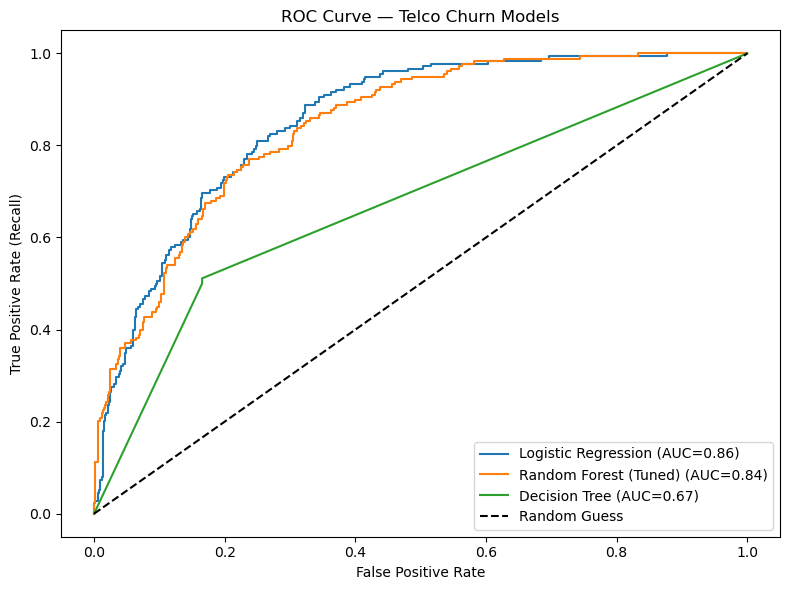

In [17]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get predicted probabilities (not just 0/1)
lr_probs   = lr.predict_proba(X_val)[:, 1]
rf_probs   = rf_tuned.predict_proba(X_val)[:, 1]
dt_probs   = dt.predict_proba(X_val)[:, 1]

# AUC scores
print("LR  AUC:", round(roc_auc_score(y_val, lr_probs), 3))
print("RF  AUC:", round(roc_auc_score(y_val, rf_probs), 3))
print("DT  AUC:", round(roc_auc_score(y_val, dt_probs), 3))

# Plot all 3 curves
plt.figure(figsize=(8, 6))
for name, probs in [("Logistic Regression", lr_probs),
                    ("Random Forest (Tuned)", rf_probs),
                    ("Decision Tree", dt_probs)]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    auc = roc_auc_score(y_val, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Telco Churn Models")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()